This file performs a grid search to visualize effect parameters where linear regression diverges from a propensity-score based estimate of causal effect.

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso, Ridge, LinearRegression
import matplotlib.pyplot as plt

np.random.seed(42)

This cell sets up the underlying condition variable U and the treatment variable X.  X is correlated with U, so this cell ends by computing the propensity score weighting factors for the data.  Feel free to explore different relationships between U and X.

In [2]:
n = 4000
U = np.random.binomial(1, 0.5, n)
UU = U.reshape(-1,1)
X = np.random.binomial(1, 0.1 + 0.25 * U, n)
D = np.column_stack((U,X))
p = LogisticRegression().fit(UU, X)
W = 1/p.predict_proba(UU)

This cell creates the data for a scatter plot visualizing the regression coefficients versus an estimate of causal effect.

In [3]:
res, bes, ces = [], [], []
max = 0
for a in np.linspace(0,1,6):
  for b in np.linspace(0,1,6) :
    for c in np.linspace(0,1,6) :
      for d in np.linspace(0,1,6) :
        Y = a * U * (1-X) + b * (1-U) * (1-X) + c * U * X + d * (1-U) * X
        re = LinearRegression().fit(D, Y).coef_[1]
        be = LinearRegression().fit(X.reshape(-1,1), Y).coef_[0]
        ce = np.mean(X * Y * W[:,1] - (1-X) * Y * W[:,0])
        res.append(re)
        bes.append(be)
        ces.append(ce)


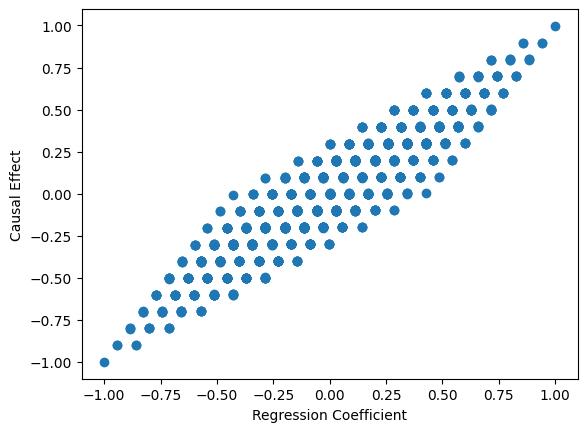

In [4]:
plt.scatter(res,ces)
plt.xlabel("Regression Coefficient")
plt.ylabel("Causal Effect")
plt.show()

In [5]:

def plot_joint(X, T, Y, area_scale=300):
    """
    Plot circles at (X, T) in {0,1}x{0,1}.

    Circle area  ~ count of joint occurrences
    Circle color ~ mean of Y for those occurrences
    Thanks Copilot!
    """
    X = np.asarray(X)
    Y = np.asarray(Y)
    T = np.asarray(T)

    coords = [(0, 0), (0, 1), (1, 0), (1, 1)]

    xs, ts, sizes, colors = [], [], [], []

    for x_val, t_val in coords:
        mask = (X == x_val) & (T == t_val)
        count = mask.sum()

        # Avoid division by zero
        y_mean = Y[mask].mean() if count > 0 else 0.0
        xs.append(x_val)
        ts.append(t_val)
        sizes.append(area_scale * count)
        colors.append(y_mean)

    fig, ax = plt.subplots()
    ax.scatter(xs, ts, s=sizes, c=colors, vmin=0, vmax=1)

    ax.set_xticks([-0.5, 0, 0.5, 1, 1.5])
    ax.set_yticks([-0.5, 0, 0.5, 1, 1.5])
    ax.set_xlabel("U")
    ax.set_ylabel("X")
    ax.set_title("Joint Distribution of U and X\nCircle Size = Count, Color = Y mean")

    plt.show()


In [6]:
a = 0
b = 1
c = 1
d = 0
Y = a * U * (1-X) + b * (1-U) * (1-X) + c * U * X + d * (1-U) * X

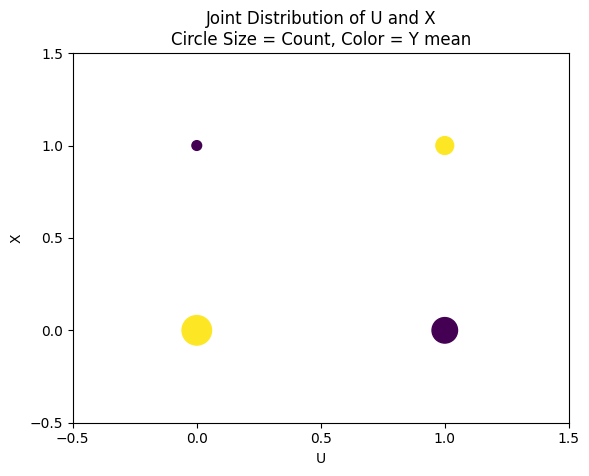

In [7]:
plot_joint(U, X, Y, area_scale=1000/n)

In [8]:
r = LinearRegression().fit(D, Y)

In [9]:
r.coef_, r.intercept_

(array([-0.67269438,  0.42755447]), np.float64(0.859889495830257))

In [10]:
r2 = LinearRegression().fit(X.reshape(-1,1), Y)

In [11]:
r2.coef_, r2.intercept_

(array([0.19775513]), np.float64(0.5719275960622419))

In [12]:
YY = X * Y * W[:,1] - (1-X) * Y * W[:,0]

In [13]:
np.mean(YY)

np.float64(0.0022211250911683606)

In [14]:
D0 = np.column_stack((U, np.zeros((n,))))
D1 = np.column_stack((U, np.ones((n,))))

In [15]:
YP0 = r.predict(D0) + (1-X) * (Y - r.predict(D)) * W[:,0]
YP1 = r.predict(D1) + X * (Y - r.predict(D)) * W[:,1]

In [16]:
ZZ = YP1 - YP0

In [17]:
np.mean(ZZ)

np.float64(0.006611679350895049)